In [1]:
# https://www.kaggle.com/competitions/lost-interpreter-aicc-round-5

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import torch
from torch import nn
import torch.nn.functional as F

In [2]:
train = pd.read_csv("/kaggle/input/competitions/lost-interpreter-aicc-round-5/train.csv")
test = pd.read_csv("/kaggle/input/competitions/lost-interpreter-aicc-round-5/test.csv")

train.shape, test.shape

((20000, 3), (5000, 2))

In [3]:
train.head()

,Unnamed: 0,program,output
0,0,OP5 13 ; OP7 -2 ; OP1 1 ; OP8 2 ; OP10 0 ; OP1...,-48
1,1,OP5 -14 ; OP12 11 ; OP8 2 ; OP4 -3 ; OP12 17 ;...,3
2,2,OP5 -14 ; OP5 -8 ; OP12 5 ; OP4 -4 ; OP6 -2 4 0 3,0
3,3,OP5 -8 ; OP6 3 4 4 0 -4 ; OP4 2,0
4,4,OP5 -14 ; OP9 4 ; OP3 6 ; OP5 6 ; OP12 18 ; OP...,49


In [4]:
train['program'].map(lambda x: x.split()[0]=='OP5').mean()

np.float64(0.91115)

In [5]:
op_set = set()

for code in train['program']:
    for elem in code.split():
        if elem.startswith('OP'):
            op_set.add(elem)

len(op_set)

12

In [6]:
op2opernum = dict([(op, set()) for op in op_set])

cur = None
cur_cnt = 0

for code in train['program']:
    for elem in code.split():
        if elem.startswith('OP'):
            cur = elem
            cur_cnt = 0
        elif elem == ';':
            op2opernum[cur].add(cur_cnt)
        else:
            cur_cnt += 1

op2opernum = {k: sorted(list(v)) for k, v in op2opernum.items()}
op2opernum

{'OP10': [1],
 'OP9': [1],
 'OP12': [1],
 'OP4': [1],
 'OP3': [1],
 'OP7': [1],
 'OP6': [2, 3, 4, 5],
 'OP1': [1],
 'OP8': [1],
 'OP2': [1],
 'OP5': [1],
 'OP11': [2]}

In [7]:
def explode(op2opernum, multiplier):
    res = dict()
    for k, v in op2opernum.items():
        for i in v:
            res[f'{k}_{i}'] = i * multiplier
    return res

multiplier = 2
op2opernum = explode(op2opernum, multiplier)
op2opernum

{'OP10_1': 2,
 'OP9_1': 2,
 'OP12_1': 2,
 'OP4_1': 2,
 'OP3_1': 2,
 'OP7_1': 2,
 'OP6_2': 4,
 'OP6_3': 6,
 'OP6_4': 8,
 'OP6_5': 10,
 'OP1_1': 2,
 'OP8_1': 2,
 'OP2_1': 2,
 'OP5_1': 2,
 'OP11_2': 4}

In [8]:
op2id = {op: i for i, op in enumerate(sorted(list(op2opernum.keys())))}
id2op = {v: k for k, v in op2id.items()}
op2id

{'OP10_1': 0,
 'OP11_2': 1,
 'OP12_1': 2,
 'OP1_1': 3,
 'OP2_1': 4,
 'OP3_1': 5,
 'OP4_1': 6,
 'OP5_1': 7,
 'OP6_2': 8,
 'OP6_3': 9,
 'OP6_4': 10,
 'OP6_5': 11,
 'OP7_1': 12,
 'OP8_1': 13,
 'OP9_1': 14}

In [9]:
from sklearn.model_selection import train_test_split

train, valid = train_test_split(train, test_size=0.1, random_state=42)
train = train.reset_index(drop=True)
valid = valid.reset_index(drop=True)

train.shape, valid.shape

((18000, 3), (2000, 3))

In [10]:
from torch.utils.data import Dataset, DataLoader

class OpDataset(Dataset):
    def __init__(self, df, op2opernum, op2id, id2op):
        self.df = df
        self.op2opernum = op2opernum
        self.op2id = op2id
        self.id2op = id2op

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        code = self.df.loc[idx, 'program']
        operations = code.split(';')

        sequence = []
        
        for oper in operations:
            elems = oper.split()
            oper_name = f'{elems[0]}_{len(elems)-1}'
            oper_data = []
            for i in range(1, len(elems)):
                oper_data.append(int(elems[i]))
            for i in range(1, len(elems)):
                if int(elems[i]) != 0:
                    oper_data.append(1 / (int(elems[i])))
                else:
                    oper_data.append(0)
            oper_data = torch.tensor(oper_data, dtype=torch.float32)
            sequence.append((self.op2id[oper_name], oper_data))

        if 'output' not in self.df.columns:
            return sequence
        output = self.df.loc[idx, 'output'].item()
        return sequence, torch.tensor(output, dtype=torch.float32)

train_ds = OpDataset(train, op2opernum, op2id, id2op)
valid_ds = OpDataset(valid, op2opernum, op2id, id2op)
test_ds = OpDataset(test, op2opernum, op2id, id2op)

len(train_ds), len(valid_ds), len(test_ds)

(18000, 2000, 5000)

In [11]:
train_ds[0]

([(7, tensor([-3.0000, -0.3333])),
  (11,
   tensor([-3.0000, -2.0000,  1.0000,  1.0000,  2.0000, -0.3333, -0.5000,  1.0000,
            1.0000,  0.5000])),
  (3, tensor([1., 1.])),
  (0, tensor([3.0000, 0.3333])),
  (1, tensor([ 2.0000, -2.0000,  0.5000, -0.5000])),
  (0, tensor([-1., -1.])),
  (8, tensor([-3.0000, -2.0000, -0.3333, -0.5000])),
  (2, tensor([-18.0000,  -0.0556])),
  (1, tensor([-5.0000, -2.0000, -0.2000, -0.5000])),
  (4, tensor([3.0000, 0.3333]))],
 tensor(10.))

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [13]:
class OpModel(nn.Module):
    def __init__(self, op2opernum, op2id, id2op, num_ops, hidden_size=64):
        super().__init__()
        self.op2opernum = op2opernum
        self.op2id = op2id
        self.id2op = id2op
        self.num_ops = num_ops
        self.hidden_size = hidden_size

        self.operators = nn.ModuleList([
            self.operator(op2opernum[id2op[i]]) for i in range(num_ops)
        ])

        self.hidden2output = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )

    def operator(self, num):
        return nn.Sequential(
            nn.Linear(self.hidden_size+num, self.hidden_size),
            nn.ReLU(),
            nn.Linear(self.hidden_size, self.hidden_size)
        )
    
    def forward(self, h, op_id, x):
        h = self.operators[op_id](torch.cat([h, x]))
        return h

    def predict(self, h):
        return self.hidden2output(h)

    def init_hidden(self):
        return torch.ones(self.hidden_size)

model = OpModel(op2opernum, op2id, id2op, len(op2opernum))
model = model.to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f'Params: {total_params}')
print(model)

Params: 132353
OpModel(
  (operators): ModuleList(
    (0): Sequential(
      (0): Linear(in_features=66, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
    )
    (1): Sequential(
      (0): Linear(in_features=68, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
    )
    (2-7): 6 x Sequential(
      (0): Linear(in_features=66, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
    )
    (8): Sequential(
      (0): Linear(in_features=68, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
    )
    (9): Sequential(
      (0): Linear(in_features=70, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
    )
    (10): Sequential(
      (0): Linear(in_features=72, out_features=64, bias=True)
      (1): ReL

In [14]:
from IPython.display import clear_output

def fit_one_epoch(model, criterion, optimizer, dataset, device):
    model.train()
    i, rloss = 0, 0
    for i in (pbar := tqdm(range(len(dataset)), desc='Train Sample', leave=False)):
        sequence, output = dataset[i]
        hidden = model.init_hidden().to(device)
        sequence = [(op_id, elems.to(device)) for op_id, elems in sequence]
        output = output.to(device)

        for op_id, elems in sequence:
            hidden = model(hidden, op_id, elems)

        pred = model.predict(hidden).squeeze()

        loss = criterion(pred, output)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        i += 1
        rloss += loss.item()
        pbar.set_postfix({'loss': f'{rloss/i:.6f}'})

    return rloss / i
    
@torch.no_grad()
def eval_one_epoch(model, criterion, dataset, device):
    model.eval()
    i, rloss = 0, 0
    for i in (pbar := tqdm(range(len(dataset)), desc='Valid Sample', leave=False)):
        sequence, output = dataset[i]
        hidden = model.init_hidden().to(device)
        sequence = [(op_id, elems.to(device)) for op_id, elems in sequence]
        output = output.to(device)

        for op_id, elems in sequence:
            hidden = model(hidden, op_id, elems)

        pred = model.predict(hidden).squeeze()

        loss = criterion(pred, output)

        i += 1
        rloss += loss.item()
        pbar.set_postfix({'loss': f'{rloss/i:.6f}'})

    return rloss / i

def plot_history(history, plot_title):
    clear_output()
    plt.figure(figsize=(10, 7))
    plt.title(plot_title)
    plt.plot(history['train_loss'], label='train')
    plt.plot(history['valid_loss'], label='valid')
    plt.legend()
    plt.show()

def fit(model, criterion, optimizer, scheduler, train_dataset, valid_dataset, device, epochs, history=None):
    if history is None:
        history = {
            'train_loss': [],
            'valid_loss': []
        }

    for epoch in range(epochs):
        tloss = fit_one_epoch(model, criterion, optimizer, train_dataset, device)
        history['train_loss'].append(tloss)
        
        vloss = eval_one_epoch(model, criterion, valid_dataset, device)
        history['valid_loss'].append(vloss)

        plot_title = f'Epoch: {epoch+1}/{epochs} | LR: {scheduler.get_last_lr()[0]:.6f}'
        plot_history(history, plot_title)
        scheduler.step()

    return history

In [15]:
epochs = 100

criterion = nn.L1Loss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)

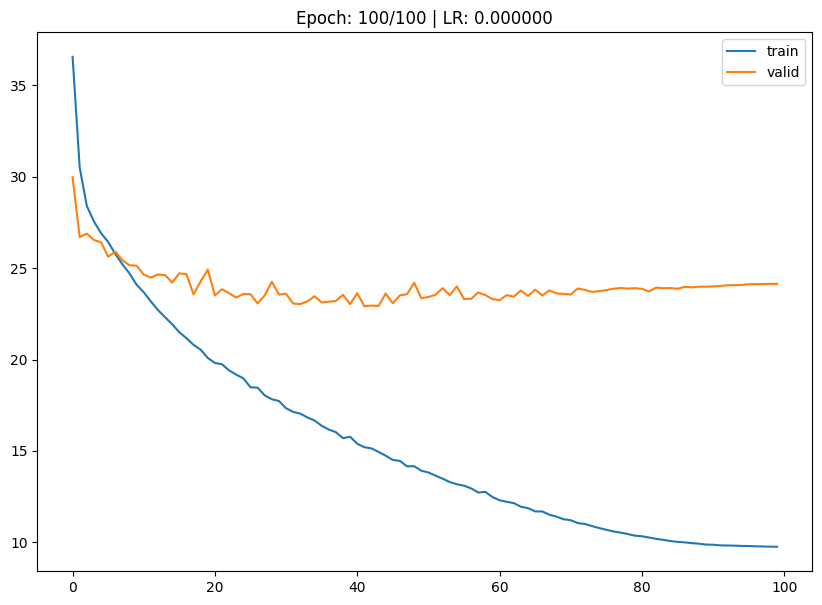

In [16]:
history = fit(model, criterion, optimizer, scheduler, train_ds, valid_ds, device, epochs)

In [17]:
@torch.no_grad()
def infer(model, dataset):
    model.eval()
    predictions = []
    for i in (pbar := tqdm(range(len(dataset)), desc='Test Sample', leave=True)):
        sequence = dataset[i]
        hidden = model.init_hidden().to(device)
        sequence = [(op_id, elems.to(device)) for op_id, elems in sequence]

        for op_id, elems in sequence:
            hidden = model(hidden, op_id, elems)

        pred = model.predict(hidden).squeeze()
        predictions.append(pred.item())

    return np.array(predictions)

preds = infer(model, test_ds)
preds.shape

Test Sample:   0%|          | 0/5000 [00:00<?, ?it/s]

(5000,)

In [18]:
subm = pd.DataFrame({
    'ID': test['ID'],
    'output': preds
})

subm.to_csv("submission.csv", index=False)

subm

,ID,output
0,0,2.549827
1,1,-6.376743
2,2,0.446722
3,3,-6.308621
4,4,27.978315
...,...,...
4995,4995,-4.151128
4996,4996,1.450491
4997,4997,-160.385147
4998,4998,-46.490681
